<a href="https://colab.research.google.com/github/KeshavFTW099/ArtificalAdvanced_NeuralNetworks/blob/main/CNN_ImageExtraction_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Trying to understand how a CNN extracts features from an image.**

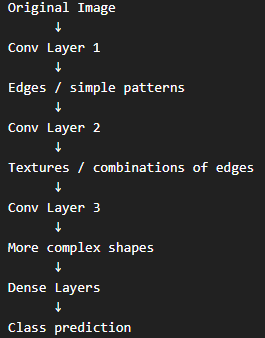

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, models, layers, callbacks
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset, CIFAR-10, which contains small colour images
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Convert image data to float32 We convert them to floating-point numbers because
# neural-network calculations work with continuous numerical values and gradients.
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Number of classes
num_labels = len(np.unique(y_train))

# Image size
image_size = x_train.shape[1]

print("Number of labels :", num_labels)
print("Image size :", image_size)
print("Training shape :", x_train.shape)
print("Testing shape :", x_test.shape)

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels into one-hot encoding
y_train_cat = to_categorical(y_train, num_labels)
y_test_cat = to_categorical(y_test, num_labels)

print("Training labels shape :", y_train_cat.shape)
print("Testing labels shape :", y_test_cat.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2024s 12us/step
Number of labels : 10
Image size : 32
Training shape : (50000, 32, 32, 3)
Testing shape : (10000, 32, 32, 3)
Training labels shape : (50000, 10)
Testing labels shape : (10000, 10)


In [4]:
# Input shape
image_size = x_train.shape[1]
input_shape = (image_size, image_size, 3)

# Training parameters
batch_size = 128
epochs = 2
validation_split = 0.1

# Create Sequential model
model = models.Sequential()

# Convolution Layer 1
model.add(layers.Conv2D(6, (5,5), activation='tanh',
                        input_shape=input_shape))

# Average Pooling Layer 1
model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

# Convolution Layer 2
model.add(layers.Conv2D(16, (5,5), activation='tanh'))

# Average Pooling Layer 2
model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

# Convolution Layer 3
model.add(layers.Conv2D(120, (5,5), activation='tanh'))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(84, activation='tanh'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Train model
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=2,  #at 2 epochs
    validation_split=0.1,
    verbose=1
)

# Evaluate model after 2 epochs
train_loss, train_acc = model.evaluate(x_train, y_train_cat, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print("Accuracy after 2 Epochs")
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - accuracy: 0.1395 - loss: 2.2846 - val_accuracy: 0.1628 - val_loss: 2.2610
Epoch 2/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.1899 - loss: 2.2271 - val_accuracy: 0.2286 - val_loss: 2.1771
Accuracy after 2 Epochs
Training Accuracy : 0.2198999971151352
Testing Accuracy  : 0.2168000042438507


In [3]:
# Train the model for 5 epochs
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

# Evaluate training accuracy
train_loss, train_acc = model.evaluate(x_train, y_train_cat, verbose=0)

# Evaluate testing accuracy
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print("Training Accuracy 5EPOCH :", train_acc)
print("Testing Accuracy 5EPOCH :", test_acc)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.2575 - loss: 2.0714 - val_accuracy: 0.2664 - val_loss: 2.0443
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.2775 - loss: 2.0275 - val_accuracy: 0.2802 - val_loss: 2.0121
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.2865 - loss: 1.9992 - val_accuracy: 0.2898 - val_loss: 1.9879
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.2966 - loss: 1.9766 - val_accuracy: 0.2986 - val_loss: 1.9684
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.3046 - loss: 1.9576 - val_accuracy: 0.3050 - val_loss: 1.9514
Training Accuracy 5EPOCH : 0.30796000361442566
Testing Accuracy 5EPOCH : 0.3057999908924103


**Alex Net** - Dealing with feature maps

In [7]:
# AlexNet Model
model = models.Sequential()

# First convolution layer
model.add(layers.Conv2D(96, (11,11),
                        input_shape=input_shape,
                        activation='relu'))

# Zero padding
model.add(layers.ZeroPadding2D((1,1)))

# Max pooling
model.add(layers.MaxPooling2D((3,3), strides=2))

# Second convolution layer
model.add(layers.Conv2D(256, (5,5),
                        activation='relu'))

# Zero padding
model.add(layers.ZeroPadding2D((1,1)))

# Max pooling
model.add(layers.MaxPooling2D((3,3), strides=1))

# Third convolution layer
model.add(layers.Conv2D(384, (3,3),
                        activation='relu'))

# Fourth convolution layer
model.add(layers.Conv2D(384, (3,3),
                        activation='relu'))

# Fifth convolution layer
model.add(layers.Conv2D(256, (3,3),
                        activation='relu'))

# Zero padding
model.add(layers.ZeroPadding2D((1,1)))

# Max pooling
model.add(layers.MaxPooling2D((3,3), strides=2))

# Flatten feature maps
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(4096, activation='relu'))

# Dropout
model.add(layers.Dropout(0.2))

# Fully connected layer
model.add(layers.Dense(4096, activation='relu'))

# Dropout
model.add(layers.Dropout(0.5))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


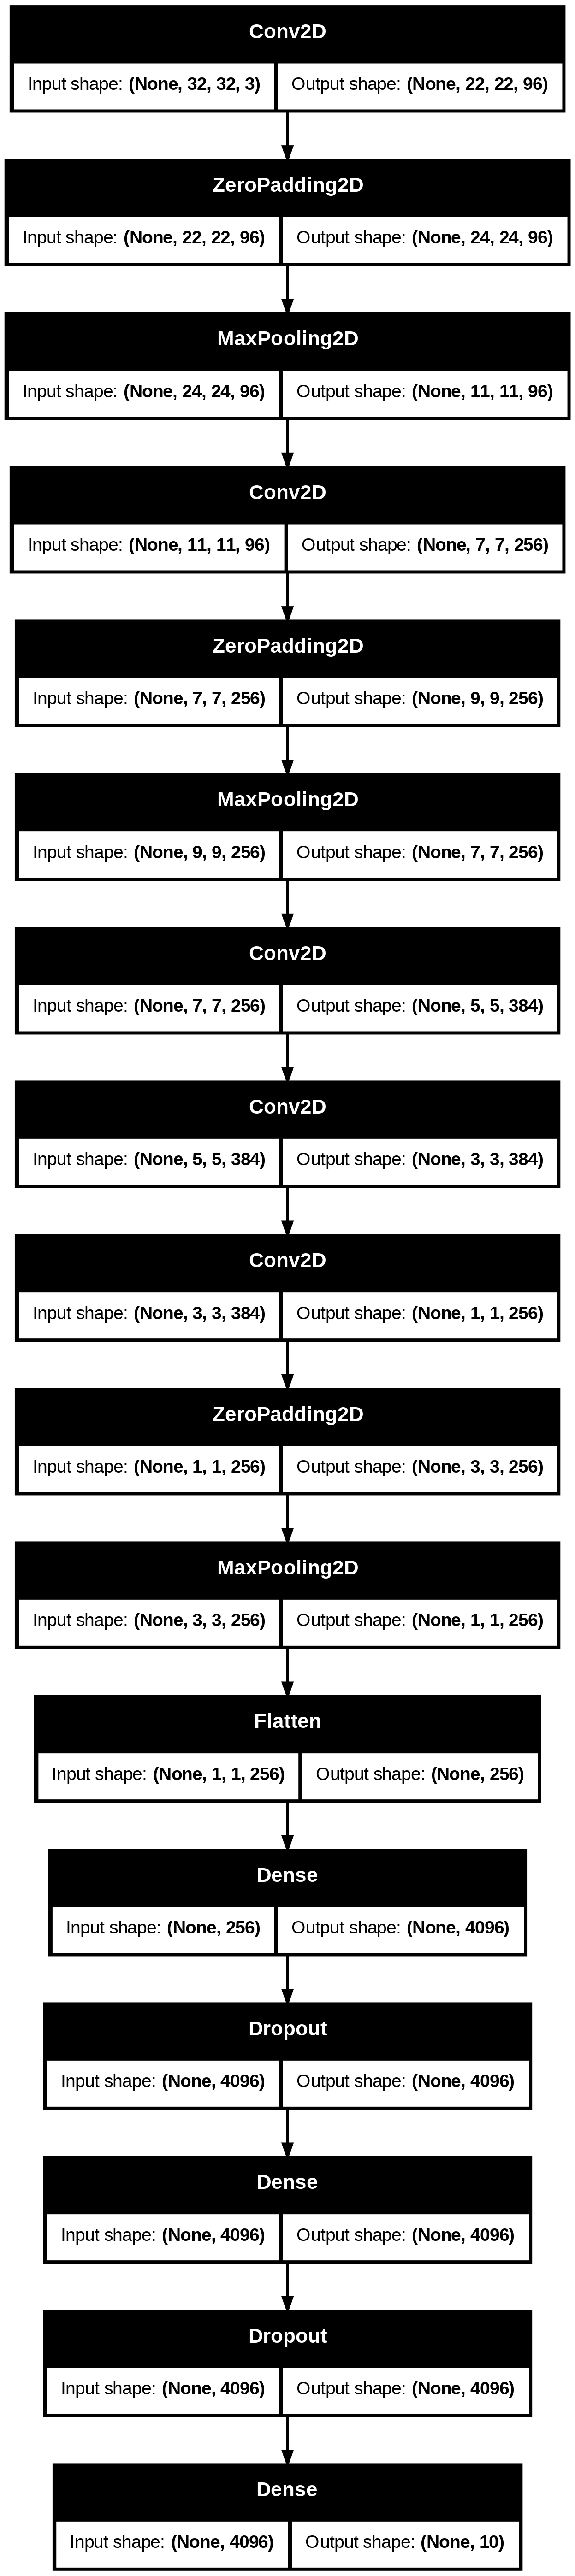

In [8]:
model.add(layers.Dense(10, activation='softmax'))
# Plot the model architecture and save it as a PNG
tf.keras.utils.plot_model(
    model,
    to_file='cnn_mnist.png',
    show_shapes=True
)

In [ ]:
# TensorBoard callback
log_dir = "logs"

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=5,
    verbose=1,
    callbacks=[tensorboard_callback]
)

# Save the trained model
model.save("sample_test099_keras.h5")

# Download the saved model in Google Colab
from google.colab import files
files.download("sample_test099_keras.h5")

# Take the first image from the training dataset
x_train_0 = x_train[0]

print("First image shape :", x_train_0.shape)

Epoch 1/5
 30/391 ━━━━━━━━━━━━━━━━━━━━ 17:03 3s/step - accuracy: 0.2667 - loss: 1.9063

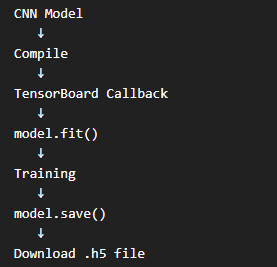